In [94]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [95]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [96]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2873,2874,15707189,Marshall,667,Germany,Female,36,1,114391.62,1,1,1,53412.54,0
8434,8435,15755330,Forbes,512,Germany,Male,41,7,122403.24,1,0,1,37439.90,1
2841,2842,15748473,Curnow,801,France,Male,38,5,0.00,2,1,0,66256.27,0
7298,7299,15789865,Nnaife,620,France,Male,28,9,71902.52,1,0,1,190208.23,0


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [98]:
df.duplicated().sum()

np.int64(0)

In [99]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [100]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [101]:
df.drop(columns = ['RowNumber',  'CustomerId' ,'Surname'],inplace=True)

In [102]:
df = pd.get_dummies(df,columns = ['Gender','Geography'],drop_first = True,dtype=int)

In [103]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,1,0


In [104]:
X = df.drop(columns=['Exited'])
y= df['Exited']

In [105]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [106]:
from sklearn.preprocessing import StandardScaler

In [107]:
scaler= StandardScaler()

In [108]:
X_train_Sc = scaler.fit_transform(X_train)
X_test_Sc =scaler.transform(X_test)

In [109]:
X_train_Sc

array([[-0.23082038, -0.94449979, -0.70174202, ...,  0.91509065,
         1.71490137, -0.57273139],
       [-0.25150912, -0.94449979, -0.35520275, ..., -1.09278791,
        -0.58312392, -0.57273139],
       [-0.3963303 ,  0.77498705,  0.33787579, ..., -1.09278791,
         1.71490137, -0.57273139],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -1.09278791,
        -0.58312392, -0.57273139],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -1.09278791,
        -0.58312392, -0.57273139],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  0.91509065,
         1.71490137, -0.57273139]])

In [110]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [111]:
model = Sequential()
model.add(Dense(11,activation = 'relu',input_dim = 11))  #Hidden layers
model.add(Dense(11,activation = 'relu')) #Hidden layers
model.add(Dense(1,activation = 'sigmoid')) #output layers

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [112]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
model.compile(loss='binary_crossentropy',optimizer ='Adam',metrics = ['accuracy'])

In [114]:
history = model.fit(X_train_Sc,y_train,epochs=36,validation_split = 0.2)

Epoch 1/36
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7967 - loss: 0.5020 - val_accuracy: 0.7975 - val_loss: 0.4668
Epoch 2/36
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7983 - loss: 0.4505 - val_accuracy: 0.8006 - val_loss: 0.4462
Epoch 3/36
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8042 - loss: 0.4360 - val_accuracy: 0.8125 - val_loss: 0.4330
Epoch 4/36
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8117 - loss: 0.4247 - val_accuracy: 0.8175 - val_loss: 0.4228
Epoch 5/36
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8200 - loss: 0.4137 - val_accuracy: 0.8250 - val_loss: 0.4114
Epoch 6/36
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8308 - loss: 0.4020 - val_accuracy: 0.8300 - val_loss: 0.3976
Epoch 7/36
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8400 - loss: 0.3887 - val_accuracy: 0.8413 - val_loss: 0.3846
Epoch 8/36
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8467 - loss: 0.3769 - val_accuracy: 0.

In [115]:
model.layers[0].get_weights()

[array([[ 9.68599506e-03, -1.04462085e-02,  1.59193113e-01,
         -1.35991022e-01,  1.18442327e-01,  3.06436252e-02,
         -3.88339087e-02, -3.23919833e-01, -1.24792479e-01,
          4.20350969e-01, -1.38214529e-01],
        [-3.65516633e-01, -1.16949856e-01, -4.10500139e-01,
         -4.36074346e-01,  7.44479671e-02,  2.05671668e-01,
          8.34264874e-01,  2.18881026e-01, -8.02700579e-01,
         -3.36142421e-01,  1.17049646e+00],
        [ 2.55404174e-01,  3.77134711e-01, -2.35475913e-01,
          2.77578324e-01, -7.84564093e-02,  3.11231315e-02,
          1.81810975e-01,  6.58700243e-02,  4.12025340e-02,
         -4.88540888e-01,  3.03832884e-03],
        [-1.39401317e-01,  1.05402566e-01,  2.94722736e-01,
         -2.44784549e-01, -7.96038359e-02,  3.20000142e-01,
         -9.22386795e-02, -8.80381539e-02, -4.39591587e-01,
         -1.04995623e-01, -3.50961447e-01],
        [-8.01760554e-02, -2.65135020e-01,  2.22764596e-01,
         -1.61800221e-01, -1.10595894e+00,  

In [116]:
model.layers[1].get_weights()

[array([[ 0.14534049, -0.43064997,  0.2820769 ,  0.5250232 ,  0.04183356,
          0.4987269 , -0.22824979,  0.21102488, -0.26897922,  0.47886986,
          0.04155689],
        [ 0.54730785, -0.42902344, -0.13689525,  0.11210622,  0.33678484,
         -0.15275083,  0.19994804,  0.43194532, -0.41048107, -0.16021171,
         -0.16772655],
        [-0.29479238,  0.33337966, -0.20931923,  0.36265334, -0.57257855,
          0.19382532, -0.21117884,  0.20704253,  0.02782997,  0.51276654,
          0.63047826],
        [-0.16861479, -0.328622  ,  0.49712723, -0.37266356,  0.14717019,
          0.14726937, -0.05716984, -0.10827436,  0.45232207,  0.48267743,
         -0.43240792],
        [-0.6514019 ,  0.5135713 , -0.196981  ,  0.08779069,  0.16744404,
          0.1603651 , -0.363722  , -0.40787655,  0.01420555,  0.09118676,
         -0.31747675],
        [-0.18229295,  0.6644447 , -0.16658166, -0.81308156, -0.4248013 ,
          1.5038661 , -0.23151352, -0.4117842 , -0.46348545, -0.2090421

In [117]:
y_log = model.predict(X_test_Sc) #Probability

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [118]:
y_pred = np.where(y_log>0.5,1,0)

In [119]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8645

In [120]:
import matplotlib.pyplot as plt

In [121]:
history.history #dictionary of training

{'accuracy': [0.7967187762260437,
  0.7982812523841858,
  0.8042187690734863,
  0.811718761920929,
  0.8199999928474426,
  0.8307812213897705,
  0.8399999737739563,
  0.8467187285423279,
  0.8514062762260437,
  0.8564062714576721,
  0.8570312261581421,
  0.8592187762260437,
  0.8598437309265137,
  0.8598437309265137,
  0.8600000143051147,
  0.8607812523841858,
  0.8595312237739563,
  0.8598437309265137,
  0.8609374761581421,
  0.8610937595367432,
  0.8606250286102295,
  0.8609374761581421,
  0.8623437285423279,
  0.8629687428474426,
  0.8623437285423279,
  0.8626562356948853,
  0.8634374737739563,
  0.862500011920929,
  0.86328125,
  0.8635937571525574,
  0.8642187714576721,
  0.8634374737739563,
  0.8642187714576721,
  0.8637499809265137,
  0.8645312786102295,
  0.8642187714576721],
 'loss': [0.5020028352737427,
  0.45051807165145874,
  0.4359627664089203,
  0.4247094690799713,
  0.4137303829193115,
  0.4020068049430847,
  0.3887014091014862,
  0.3769129812717438,
  0.3666208386421203

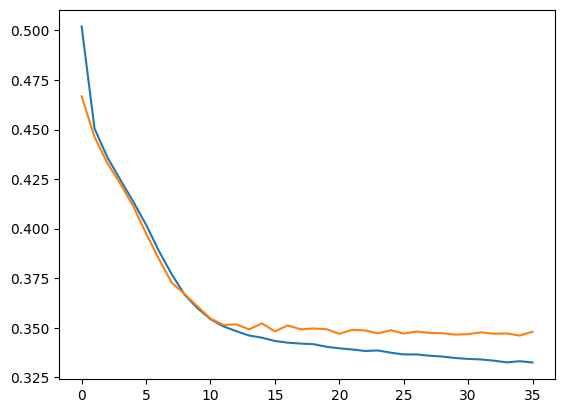

In [124]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

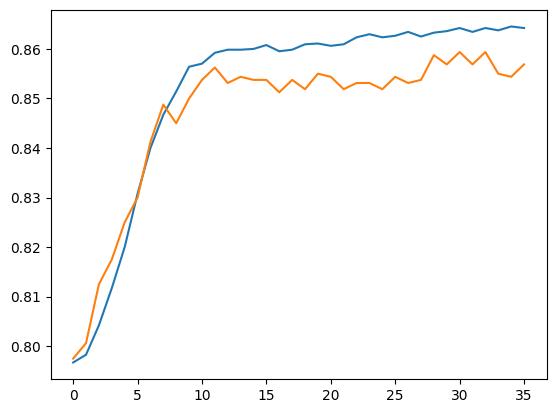

In [125]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])